In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/Pharma_Industry (2).csv')
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [4]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
df.shape

(500, 6)

In [8]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


<Axes: >

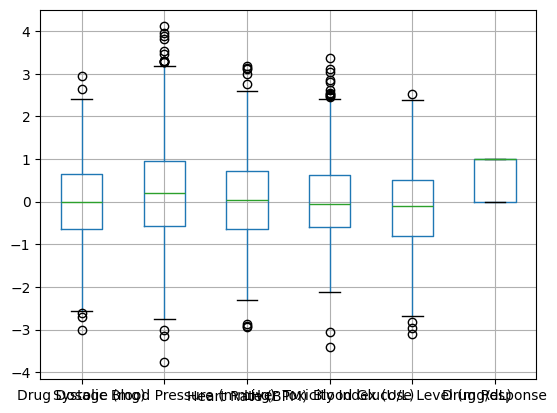

In [9]:
df.boxplot()

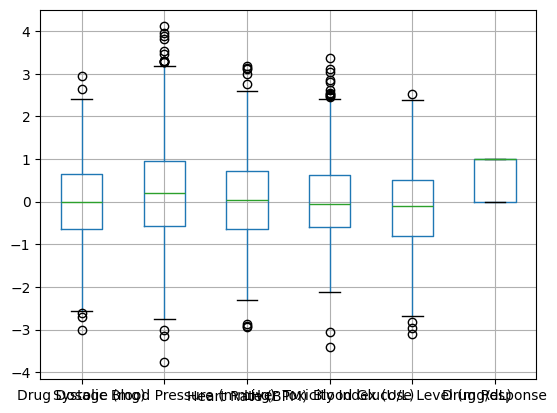

In [12]:
#Checking outliers
df.boxplot()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [15]:
df.columns


Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [16]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


In [19]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


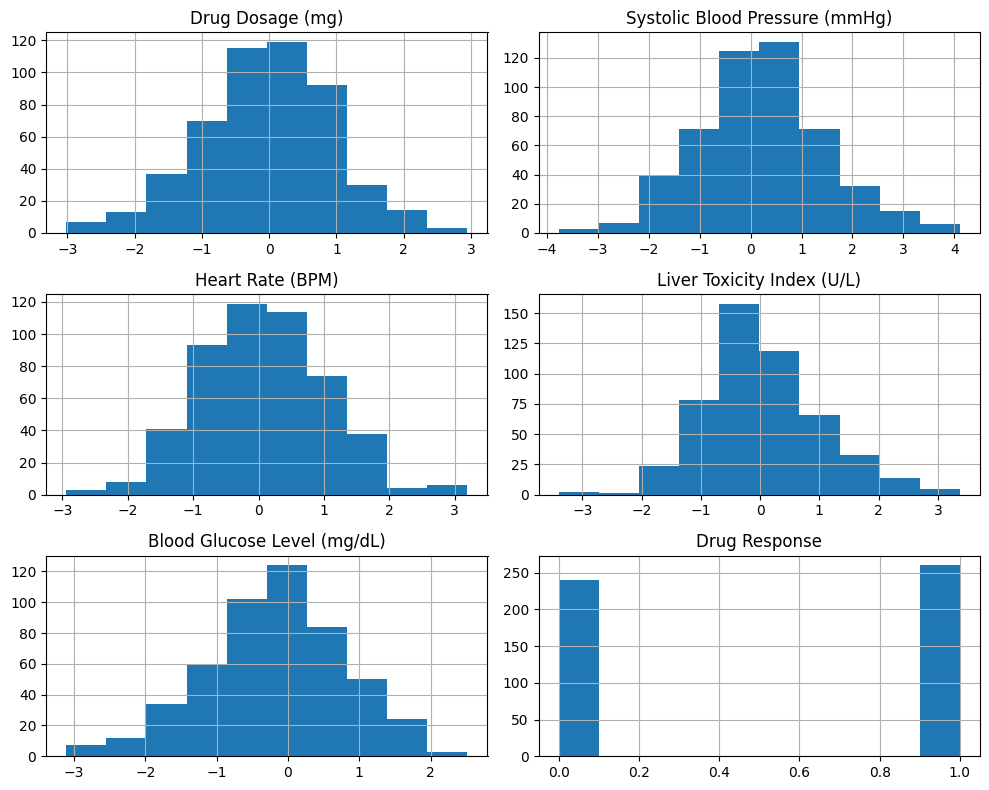

In [20]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()



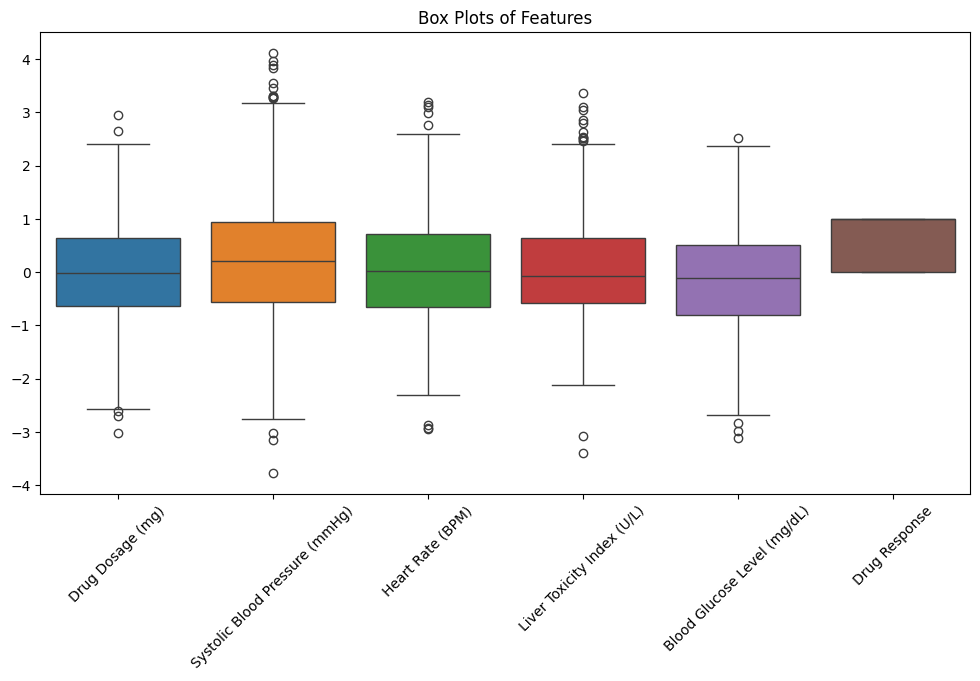

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Box Plots of Features')
plt.show()


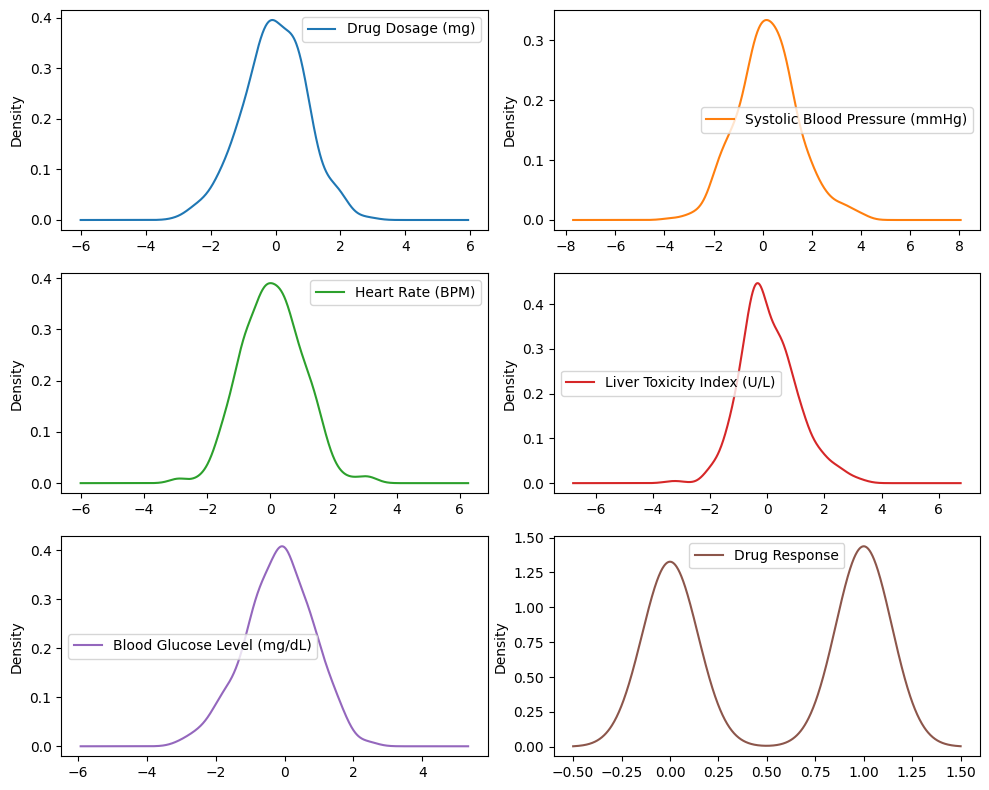

In [22]:
df.plot(kind='density', subplots=True, layout=(3,2), figsize=(10,8), sharex=False)
plt.tight_layout()
plt.show()


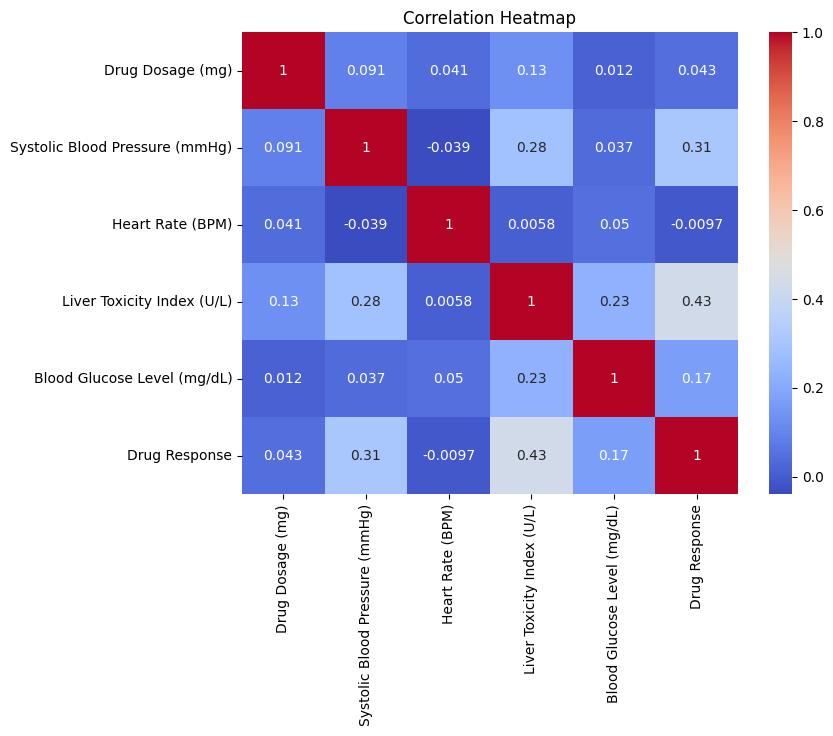

In [23]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [25]:
#Data Preprocessing

# Target column
target_col = 'Drug Response'

# Features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('\\nTraining Set Shape:', X_train.shape)
print('Testing Set Shape:', X_test.shape)

\nTraining Set Shape: (400, 5)
Testing Set Shape: (100, 5)


In [26]:
# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


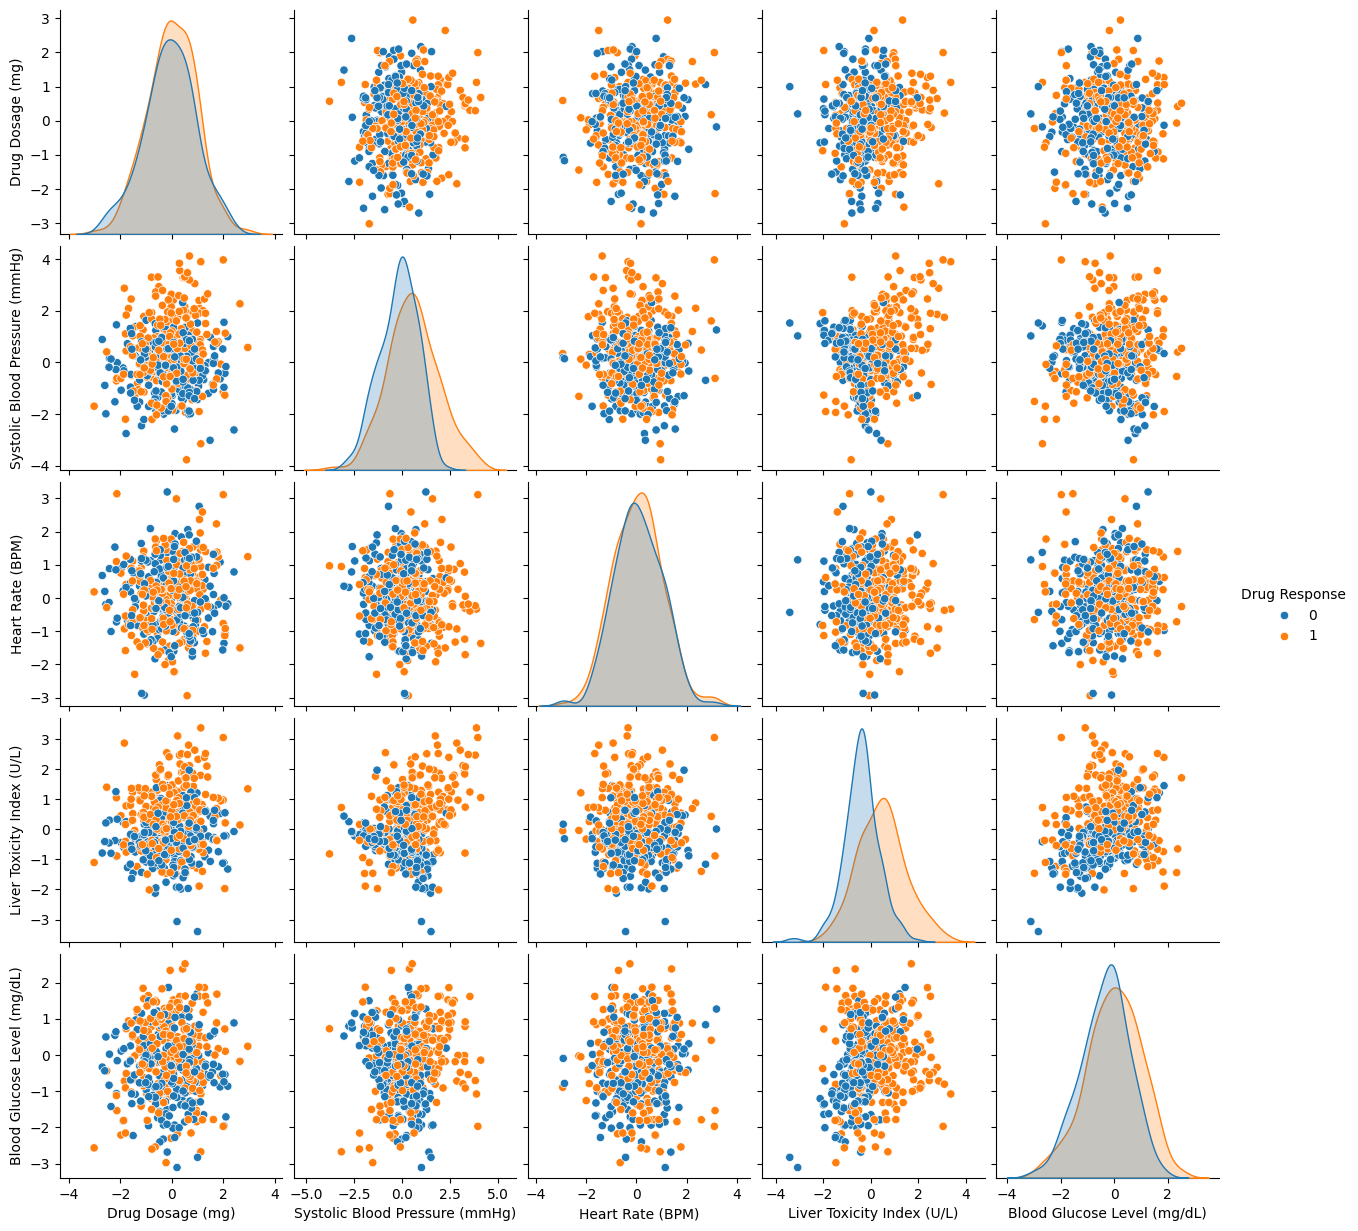

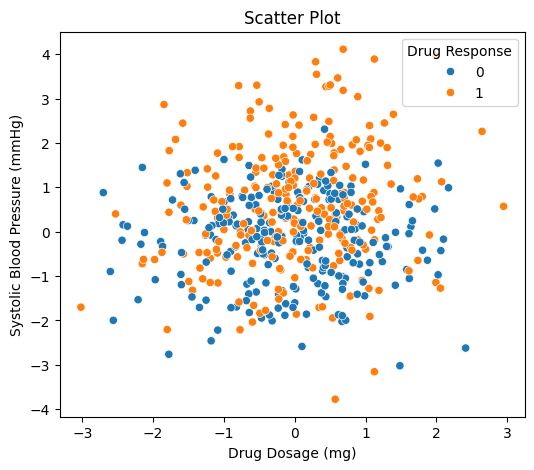

In [31]:
 #Data Visualization

#Pair Plot
sns.pairplot(df, hue=target_col)
plt.show()

# Scatter Plot
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df.columns[0],
    y=df.columns[1],
    hue=df[target_col],
    data=df
)
plt.title('Scatter Plot')
plt.show()

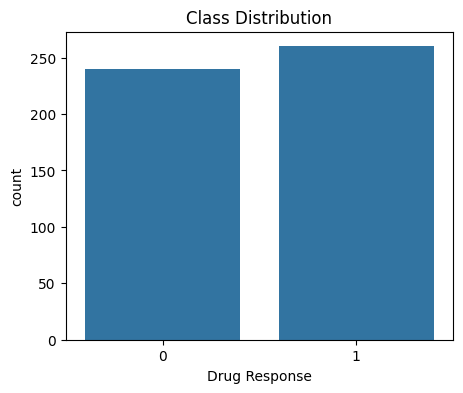

In [32]:
# Class Distribution
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title('Class Distribution')
plt.show()


In [34]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)



In [35]:
print('\\n===== LINEAR SVM RESULTS =====')
print('Accuracy:', accuracy_score(y_test, y_pred_linear))

print('\\nClassification Report:')
print(classification_report(y_test, y_pred_linear))



\n===== LINEAR SVM RESULTS =====
Accuracy: 0.72
\nClassification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



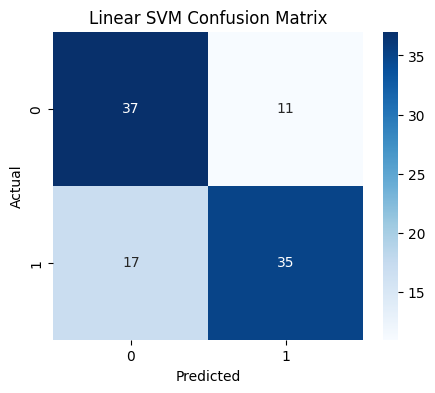

In [36]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(5,4))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title('Linear SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


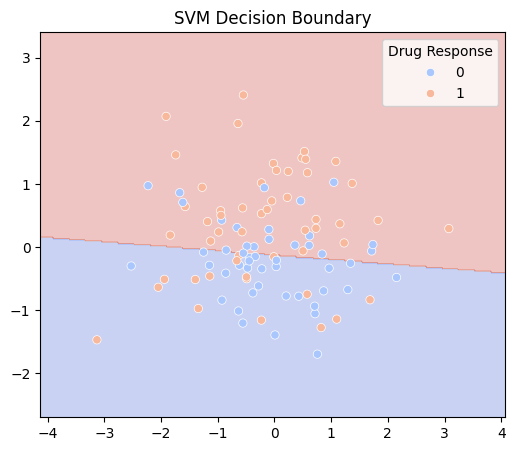

In [38]:
#Visualization of SVM Results
X_vis = X.iloc[:, :2]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y, test_size=0.2, random_state=42, stratify=y
)

scaler_vis = StandardScaler()
X_train_vis = scaler_vis.fit_transform(X_train_vis)
X_test_vis = scaler_vis.transform(X_test_vis)

svm_vis = SVC(kernel='linear')
svm_vis.fit(X_train_vis, y_train_vis)

# Mesh grid
x_min, x_max = X_test_vis[:,0].min()-1, X_test_vis[:,0].max()+1
y_min, y_max = X_test_vis[:,1].min()-1, X_test_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(
    x=X_test_vis[:,0],
    y=X_test_vis[:,1],
    hue=y_test_vis,
    palette='coolwarm'
)
plt.title('SVM Decision Boundary')
plt.show()


In [39]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print('\\nBest Parameters:', grid.best_params_)
print('Best Cross-Validation Accuracy:', grid.best_score_)



\nBest Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7525000000000001


In [40]:
# Best model
best_model = grid.best_estimator_

# Predictions
y_pred_best = best_model.predict(X_test)

print('\\n===== TUNED SVM RESULTS =====')
print('Accuracy:', accuracy_score(y_test, y_pred_best))

print('\\nClassification Report:')
print(classification_report(y_test, y_pred_best))



\n===== TUNED SVM RESULTS =====
Accuracy: 0.77
\nClassification Report:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [41]:
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[k] = acc

print('\\nKernel Comparison:')
for k, v in results.items():
    print(f'{k}: {v:.4f}')


\nKernel Comparison:
linear: 0.7200
poly: 0.6500
rbf: 0.7700


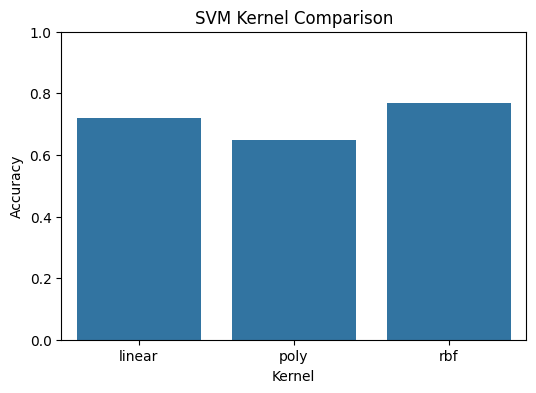

In [42]:
# Bar plot comparison
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel('Accuracy')
plt.xlabel('Kernel')
plt.title('SVM Kernel Comparison')
plt.ylim(0,1)
plt.show()


In [43]:
#Analysis

best_kernel = max(results, key=results.get)

print('\\nBest Kernel:', best_kernel)

print('\\nStrengths of SVM:')
print('- Works well with high-dimensional data')
print('- Effective for classification problems')
print('- Can model non-linear relationships using kernels')

print('\\nWeaknesses of SVM:')
print('- Sensitive to parameter tuning')
print('- Computationally expensive for large datasets')
print('- Less interpretable than linear models')

print('\\nPractical Implications:')
print('SVM can help pharmaceutical companies predict patient drug response early,')
print('support personalized medicine, and reduce clinical trial costs.')



\nBest Kernel: rbf
\nStrengths of SVM:
- Works well with high-dimensional data
- Effective for classification problems
- Can model non-linear relationships using kernels
\nWeaknesses of SVM:
- Sensitive to parameter tuning
- Computationally expensive for large datasets
- Less interpretable than linear models
\nPractical Implications:
SVM can help pharmaceutical companies predict patient drug response early,
support personalized medicine, and reduce clinical trial costs.


In [44]:
# Final Conclusion
# ------------------------------------------------------------
print('\\nFINAL CONCLUSION')
print('Support Vector Machine models were successfully implemented for drug response classification.')
print('EDA revealed the distribution and relationships among clinical features.')
print('Different kernels were compared, and the best-performing kernel was identified.')
print('The optimized SVM model demonstrated strong classification performance and can support')
print('personalized treatment decisions and pharmaceuticalresearch.')

\nFINAL CONCLUSION
Support Vector Machine models were successfully implemented for drug response classification.
EDA revealed the distribution and relationships among clinical features.
Different kernels were compared, and the best-performing kernel was identified.
The optimized SVM model demonstrated strong classification performance and can support
personalized treatment decisions and pharmaceuticalresearch.


# Drug Response Classification using Support Vector Machine

# Objective

To develop an SVM-based machine learning model that predicts whether a patient will show a positive response (1) or no response (0) to a drug using clinical features from the Pharma_Industry dataset.


## Conclusion

Support Vector Machine models were implemented to classify patient drug response using the Pharma_Industry dataset. Exploratory Data Analysis helped understand feature distributions, outliers, and correlations. The dataset was preprocessed and divided into training and testing sets. SVM models with linear, polynomial, and RBF kernels were trained and evaluated. Hyperparameter tuning was performed to improve model performance. The optimized model achieved strong classification results and demonstrated the usefulness of SVM for healthcare classification tasks.
